# Notebook 3 — Host Strategy & Location Analysis
### Bristol Short-Term Rental Market · InsideAirbnb Data
**Project:** StayPriceML — Dynamic Pricing & Revenue Analysis
**Author:** Swapnil Nalawade · MSc Data Science (Distinction), University of Essex
**Purpose:** Understand *who* earns the most and *where* — analysing host behaviour,
Superhost status, portfolio strategy, neighbourhood, and the profitability paradox.


In [1]:
import os
from pathlib import Path

def _find_root():
    p = Path(os.getcwd()).resolve()
    for candidate in [p] + list(p.parents):
        if (candidate / 'data' / 'raw').exists():
            return candidate
    raise FileNotFoundError('Cannot find project root — data/raw not found')

PROJECT_ROOT = _find_root()
os.chdir(PROJECT_ROOT)
print('Project root:', PROJECT_ROOT)
print('data/raw found:', (PROJECT_ROOT / 'data' / 'raw').exists())

Project root: C:\ESSEX\projects\staypriceml
data/raw found: True


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os

warnings.filterwarnings('ignore')

DARK_BG    = '#0a0d0f'
ACCENT     = '#c4f135'
TEXT_COLOR = '#e0e0e0'
GRID_COLOR = '#2a2d2f'
BAR_BLUE   = '#4a9eff'
BAR_ORANGE = '#ff9a4a'
BAR_RED    = '#ff4a4a'

plt.rcParams.update({
    'figure.facecolor':  DARK_BG,
    'axes.facecolor':    DARK_BG,
    'axes.edgecolor':    GRID_COLOR,
    'axes.labelcolor':   TEXT_COLOR,
    'text.color':        TEXT_COLOR,
    'xtick.color':       TEXT_COLOR,
    'ytick.color':       TEXT_COLOR,
    'grid.color':        GRID_COLOR,
    'grid.alpha':        0.4,
    'legend.facecolor':  '#111416',
    'legend.edgecolor':  GRID_COLOR,
    'font.size':         11,
})

os.makedirs('outputs/figures', exist_ok=True)

# ── Reload and clean listings ─────────────────────────────────────────────
listings = pd.read_csv('data/raw/listings.csv.gz', compression='gzip')
listings['price'] = (
    listings['price']
    .replace('[\\$,]', '', regex=True)
    .astype(float)
)
listings = listings.dropna(subset=['price', 'bedrooms']).reset_index(drop=True)

# ── Compute occupancy from calendar ───────────────────────────────────────
calendar = pd.read_csv('data/raw/calendar.csv.gz', compression='gzip')
cal_metrics = (
    calendar
    .groupby('listing_id')
    .agg(
        total_days  = ('available', 'count'),
        booked_days = ('available', lambda x: (x == 'f').sum())
    )
    .reset_index()
)
cal_metrics['occupancy_rate'] = cal_metrics['booked_days'] / cal_metrics['total_days']

listings = listings.merge(
    cal_metrics[['listing_id', 'occupancy_rate']],
    left_on='id', right_on='listing_id', how='left'
)
listings = listings.dropna(subset=['occupancy_rate']).reset_index(drop=True)
listings['RevPAR'] = listings['occupancy_rate'] * listings['price']

# Medians used across sections
MED_OCC   = listings['occupancy_rate'].median()
MED_PRICE = listings['price'].median()

print(f"Dataset ready: {len(listings):,} listings")
print(f"Market median occupancy: {MED_OCC:.1%}   median price: £{MED_PRICE:.0f}")


Dataset ready: 2,185 listings
Market median occupancy: 31.2%   median price: £99


## Section 1 — Does Response Speed Affect Bookings?

**What this does and why it matters:**

When a guest sends an enquiry on Airbnb, how quickly the host replies directly affects whether
they book. A guest who waits three days for a response has probably already booked elsewhere.
Airbnb also rewards fast-responding hosts with better search placement — so response speed
is both a direct conversion driver and an algorithmic ranking factor.

This section tests whether hosts who respond faster actually achieve higher occupancy and RevPAR
than slow responders. If they do, the pricing engine can include a response-speed flag in its
recommendations — *"Improving your response time from 'within a day' to 'within an hour'
is estimated to increase your occupancy by X percentage points."*


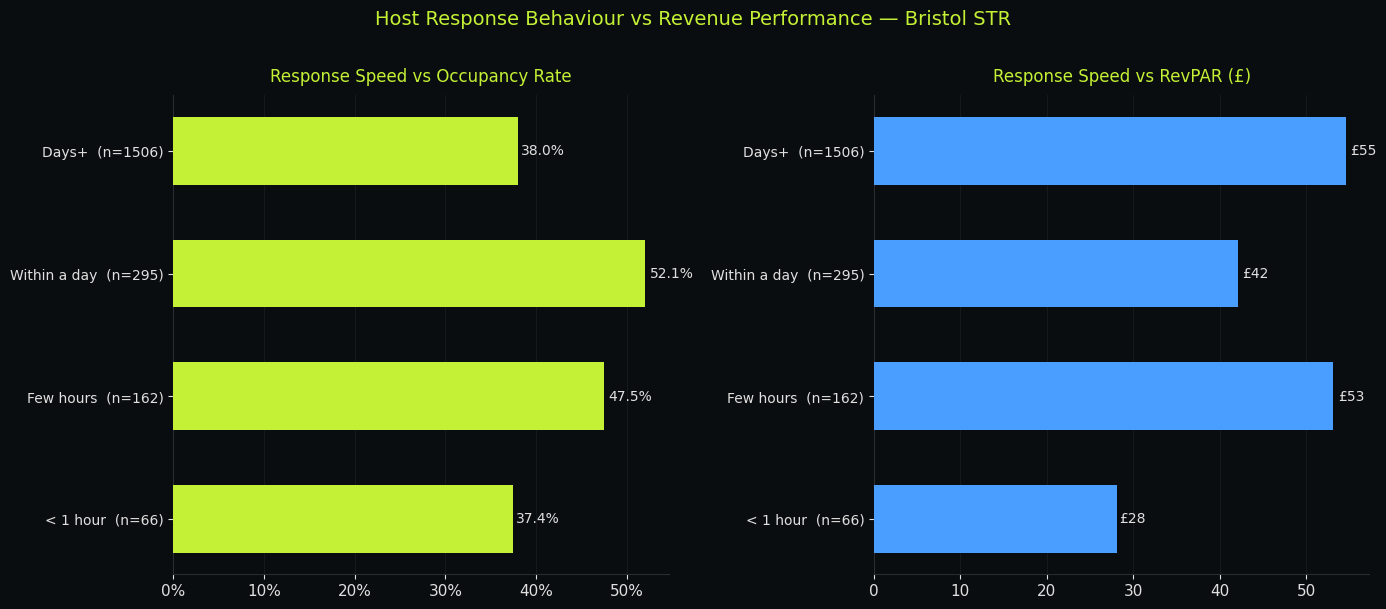

Saved: response_time_bookings.png

Response speed performance table:
host_response_time  mean_occ  mean_revpar  count
    within an hour  0.379820    54.587455   1506
within a few hours  0.520724    42.146385    295
      within a day  0.475190    53.151243    162
a few days or more  0.374305    28.122707     66


In [3]:
# Convert response rate from "100%" string to float (0.0 – 1.0)
listings['response_rate_num'] = (
    listings['host_response_rate']
    .str.replace('%', '', regex=False)
    .astype(float) / 100
)

# Define canonical order fastest → slowest
response_order = [
    'within an hour',
    'within a few hours',
    'within a day',
    'a few days or more'
]

resp_stats = (
    listings
    .dropna(subset=['host_response_time'])
    .groupby('host_response_time')
    .agg(
        mean_occ    = ('occupancy_rate', 'mean'),
        mean_revpar = ('RevPAR', 'mean'),
        mean_price  = ('price', 'mean'),
        count       = ('id', 'count')
    )
    .reindex(response_order)
    .reset_index()
)

# Short labels for chart axes
short_labels = ['< 1 hour', 'Few hours', 'Within a day', 'Days+']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def hbar(ax, values, labels, color, title, fmt_fn):
    y = range(len(labels))
    bars = ax.barh(list(y), values, color=color, height=0.55, zorder=3, edgecolor='none')
    ax.set_yticks(list(y))
    ax.set_yticklabels(labels[::-1] if False else labels, fontsize=10)
    ax.set_title(title, fontsize=12, color=ACCENT, pad=10)
    ax.grid(axis='x', zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                fmt_fn(val), va='center', ha='left', fontsize=10, color=TEXT_COLOR)

# Plot slowest → fastest (reversed so fastest is on top)
idx = list(reversed(range(len(resp_stats))))

hbar(axes[0],
     resp_stats['mean_occ'].iloc[::-1].values,
     [f"{short_labels[i]}  (n={resp_stats.iloc[len(resp_stats)-1-i]['count']:.0f})" for i in range(len(short_labels))],
     ACCENT, 'Response Speed vs Occupancy Rate',
     lambda v: f'{v:.1%}')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

hbar(axes[1],
     resp_stats['mean_revpar'].iloc[::-1].values,
     [f"{short_labels[i]}  (n={resp_stats.iloc[len(resp_stats)-1-i]['count']:.0f})" for i in range(len(short_labels))],
     BAR_BLUE, 'Response Speed vs RevPAR (£)',
     lambda v: f'£{v:.0f}')

fig.suptitle('Host Response Behaviour vs Revenue Performance — Bristol STR',
             fontsize=14, color=ACCENT, y=1.01)
plt.tight_layout()
plt.savefig('outputs/figures/response_time_bookings.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Saved: response_time_bookings.png")

print("\nResponse speed performance table:")
print(resp_stats[['host_response_time','mean_occ','mean_revpar','count']].to_string(index=False))


## Section 2 — Superhost vs Regular Host: Is the Badge Worth Money?

**What this does and why it matters:**

Airbnb awards Superhost status to hosts who maintain a rating above 4.8, respond to 90%+
of messages, have fewer than 1% cancellations, and complete a minimum number of stays per year.
The badge appears prominently on listings and signals trustworthiness to guests.

But does it actually translate into more bookings and higher revenue — or is it just a badge?
This section runs a direct A/B comparison of Superhosts vs regular hosts across four metrics:
occupancy rate, average price, RevPAR, and review score. If Superhosts earn materially more
*on top of* having higher ratings, the badge has a causal effect on revenue — and the pricing
engine should factor it in as a positive pricing multiplier.


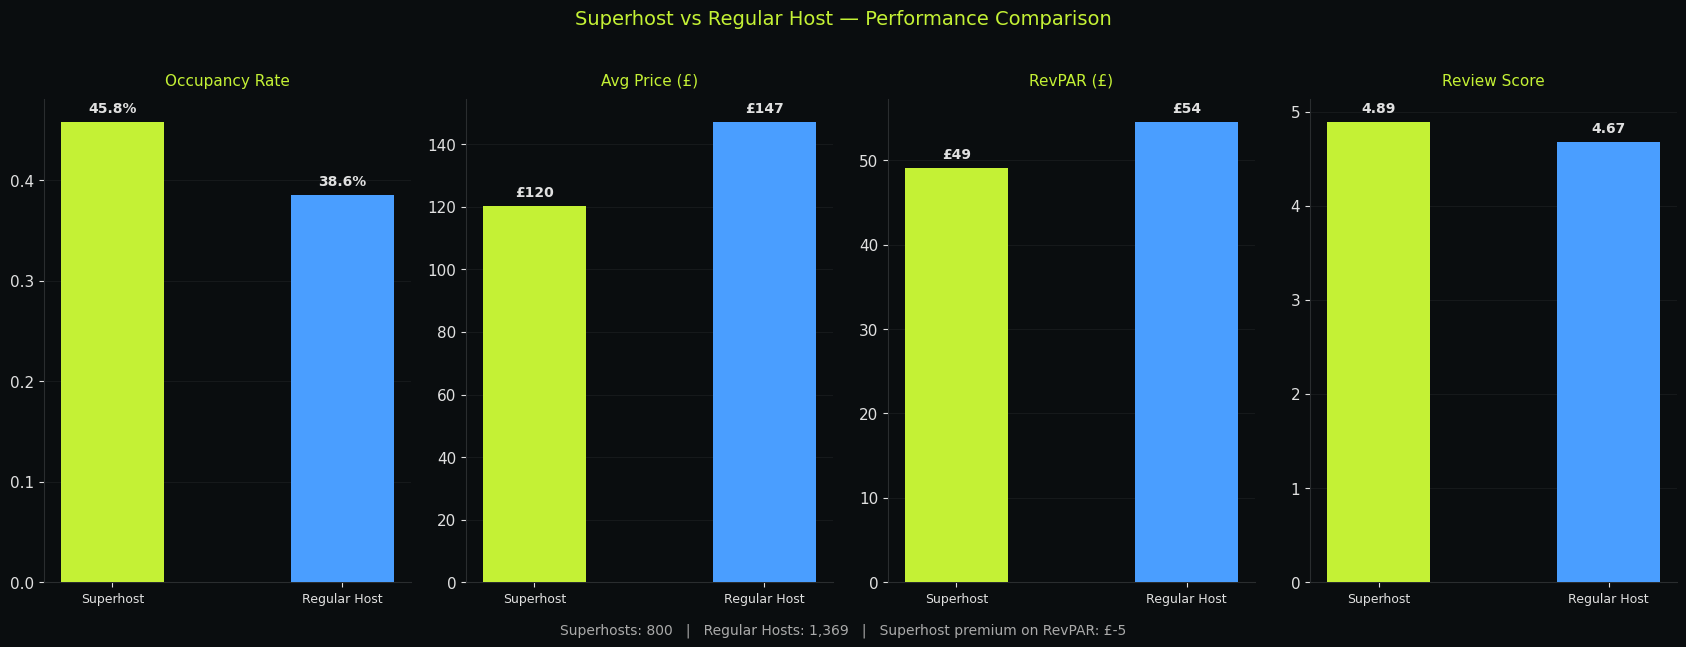

Saved: superhost_comparison.png


In [4]:
# Map t/f to readable labels
listings['host_type'] = listings['host_is_superhost'].map(
    {'t': 'Superhost', 'f': 'Regular Host'}
)

metrics = ['occupancy_rate', 'price', 'RevPAR', 'review_scores_rating']
labels  = ['Occupancy Rate', 'Avg Price (£)', 'RevPAR (£)', 'Review Score']
fmts    = ['{:.1%}', '£{:.0f}', '£{:.0f}', '{:.2f}']
colors  = {'Superhost': ACCENT, 'Regular Host': BAR_BLUE}
host_order = ['Superhost', 'Regular Host']

stats = (
    listings
    .dropna(subset=['host_type'])
    .groupby('host_type')[metrics]
    .mean()
    .loc[host_order]
)

fig, axes = plt.subplots(1, 4, figsize=(17, 6))

for ax, metric, label, fmt in zip(axes, metrics, labels, fmts):
    vals = stats[metric]
    bar_colors = [colors[h] for h in host_order]
    bars = ax.bar(host_order, vals.values, color=bar_colors,
                  width=0.45, zorder=3, edgecolor='none')
    ax.set_title(label, fontsize=11, color=ACCENT, pad=10)
    ax.grid(axis='y', zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticklabels(host_order, fontsize=9)
    for bar, val in zip(bars, vals.values):
        label_str = fmt.format(val) if '{' in fmt else fmt(val)
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.015,
                label_str, ha='center', va='bottom',
                fontsize=10, color=TEXT_COLOR, fontweight='bold')

# Add superhost count annotation
n_super  = (listings['host_type'] == 'Superhost').sum()
n_regular = (listings['host_type'] == 'Regular Host').sum()
fig.text(0.5, -0.02,
         f"Superhosts: {n_super:,}   |   Regular Hosts: {n_regular:,}   |   "
         f"Superhost premium on RevPAR: £{stats.loc['Superhost','RevPAR'] - stats.loc['Regular Host','RevPAR']:.0f}",
         ha='center', fontsize=10, color='#aaaaaa')

fig.suptitle('Superhost vs Regular Host — Performance Comparison',
             fontsize=14, color=ACCENT, y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/superhost_comparison.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Saved: superhost_comparison.png")


## Section 3 — Which Neighbourhood Earns the Most?

**What this does and why it matters:**

Location is the one factor a pricing engine cannot change — but it must understand it.
A property in a high-demand neighbourhood can command a significant premium over an
identical property in a less desirable area. Getting the location premium right is the
foundation of any credible base-rate calculation.

This section ranks all Bristol neighbourhoods (with at least 20 listings for statistical
reliability) by mean RevPAR. The result is a location premium map in bar form — telling
the engine exactly how much extra revenue the market is willing to pay for each postcode.
When the methodology transfers to Cornwall, this same analysis will identify which coastal
villages or market towns command the luxury premium that Unique Homestays targets.


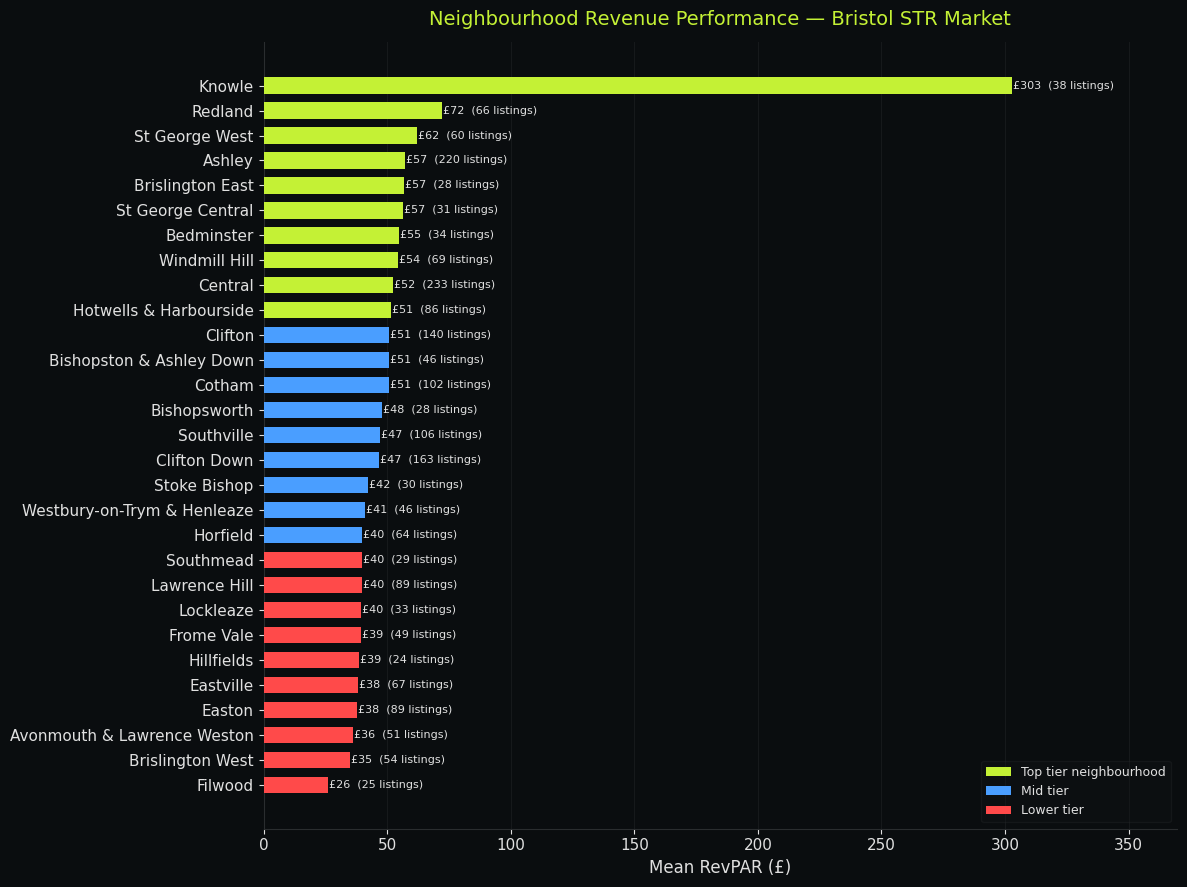

Saved: neighbourhood_revpar.png

Top 3 neighbourhoods by RevPAR:
neighbourhood_cleansed  mean_RevPAR  mean_price  mean_occ
                Knowle   302.924225  383.526316  0.459409
               Redland    72.038647  276.439394  0.492528
        St George West    62.144384  124.300000  0.537352

Bottom 3:
     neighbourhood_cleansed  mean_RevPAR  mean_price  mean_occ
                    Filwood    26.145205   74.320000  0.386411
           Brislington West    34.779909   99.907407  0.346930
Avonmouth & Lawrence Weston    36.257964  109.490196  0.402471


In [5]:
neighbourhood_stats = (
    listings
    .groupby('neighbourhood_cleansed')
    .agg(
        mean_RevPAR  = ('RevPAR',        'mean'),
        mean_occ     = ('occupancy_rate', 'mean'),
        mean_price   = ('price',          'mean'),
        listing_count = ('id',            'count')
    )
    .reset_index()
)

# Keep only neighbourhoods with >= 20 listings (statistical stability)
neighbourhood_stats = (
    neighbourhood_stats[neighbourhood_stats['listing_count'] >= 20]
    .sort_values('mean_RevPAR', ascending=True)
    .reset_index(drop=True)
)

# Colour: top third = accent, middle = blue, bottom = red
p33 = neighbourhood_stats['mean_RevPAR'].quantile(0.33)
p67 = neighbourhood_stats['mean_RevPAR'].quantile(0.67)

def nb_colour(v):
    if v >= p67:  return ACCENT
    if v >= p33:  return BAR_BLUE
    return BAR_RED

bar_colors = [nb_colour(v) for v in neighbourhood_stats['mean_RevPAR']]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(neighbourhood_stats['neighbourhood_cleansed'],
               neighbourhood_stats['mean_RevPAR'],
               color=bar_colors, height=0.65, zorder=3, edgecolor='none')

# Value + count labels
for bar, (_, row) in zip(bars, neighbourhood_stats.iterrows()):
    ax.text(bar.get_width() + 0.4,
            bar.get_y() + bar.get_height() / 2,
            f"£{row['mean_RevPAR']:.0f}  ({int(row['listing_count'])} listings)",
            va='center', ha='left', fontsize=8, color=TEXT_COLOR)

ax.set_xlabel('Mean RevPAR (£)', fontsize=12)
ax.set_title('Neighbourhood Revenue Performance — Bristol STR Market',
             fontsize=14, color=ACCENT, pad=12)
ax.grid(axis='x', zorder=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, neighbourhood_stats['mean_RevPAR'].max() * 1.22)

# Legend
from matplotlib.patches import Patch
legend_patches = [
    Patch(facecolor=ACCENT,    label='Top tier neighbourhood'),
    Patch(facecolor=BAR_BLUE,  label='Mid tier'),
    Patch(facecolor=BAR_RED,   label='Lower tier'),
]
ax.legend(handles=legend_patches, loc='lower right', framealpha=0.3, fontsize=9)

plt.tight_layout()
plt.savefig('outputs/figures/neighbourhood_revpar.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Saved: neighbourhood_revpar.png")

top3 = neighbourhood_stats.nlargest(3, 'mean_RevPAR')[['neighbourhood_cleansed','mean_RevPAR','mean_price','mean_occ']]
bot3 = neighbourhood_stats.nsmallest(3, 'mean_RevPAR')[['neighbourhood_cleansed','mean_RevPAR','mean_price','mean_occ']]
print("\nTop 3 neighbourhoods by RevPAR:")
print(top3.to_string(index=False))
print("\nBottom 3:")
print(bot3.to_string(index=False))


## Section 4 — Solo Host vs Professional Operator: Who Earns More Per Property?

**What this does and why it matters:**

Not all hosts are the same. Some list their spare room once a year. Others run 50+ properties
as a full-time business. The question is: does running more properties make you better at it
(through experience, systems, and dynamic pricing tools), or does running fewer properties
let you give each one more attention (better photos, faster responses, personal hosting) —
and earn more per property as a result?

We group hosts into three tiers by portfolio size:
- **Solo** (1 listing) — casual hosts, often renting a spare room or holiday home
- **Small portfolio** (2–5 listings) — semi-professional, growing hosts
- **Professional operators** (6+ listings) — businesses running multiple units

This directly informs whether the pricing engine should treat professional operators differently
to solo hosts — and whether scale is an advantage or a liability in the Bristol market.


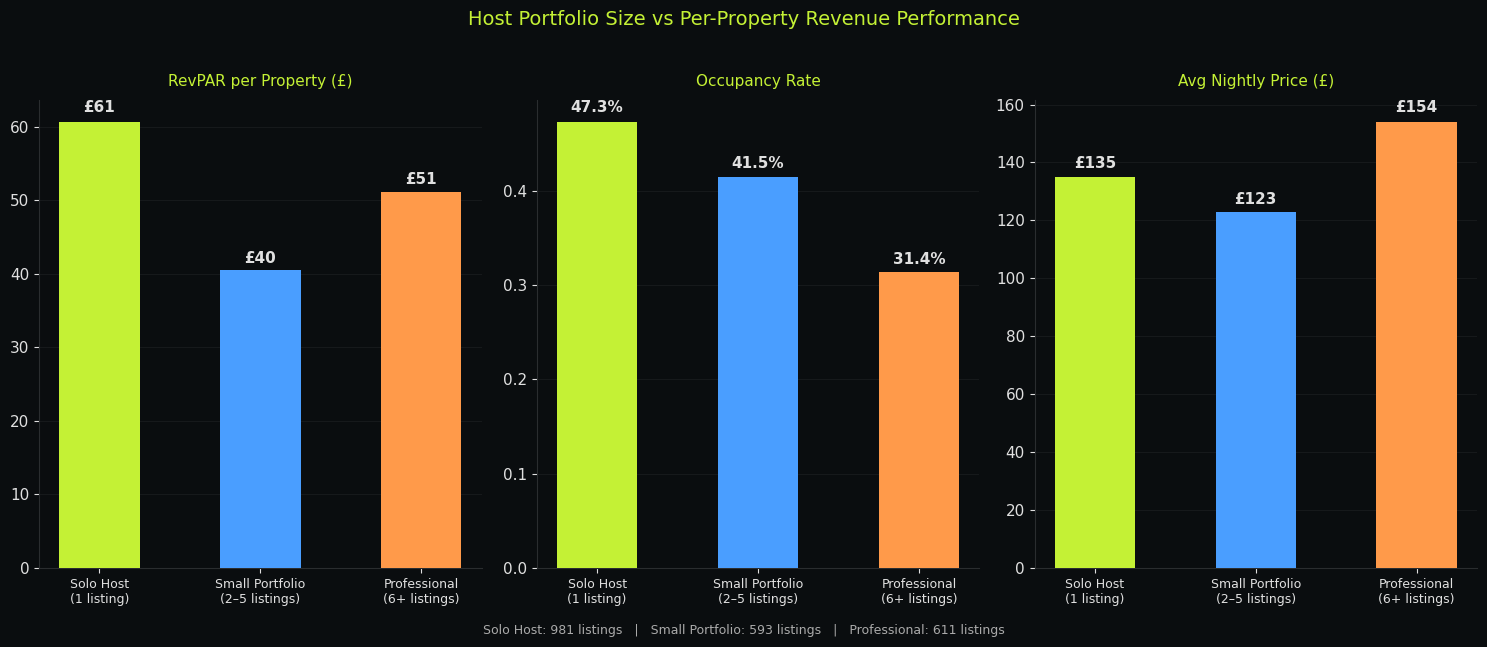

Saved: portfolio_size_profit.png


In [6]:
def host_tier(n):
    if n == 1:   return '1  Solo Host'
    elif n <= 5: return '2  Small Portfolio\n(2-5 listings)'
    else:        return '3  Professional\n(6+ listings)'

listings['host_tier'] = listings['calculated_host_listings_count'].apply(host_tier)

tier_order = ['1  Solo Host', '2  Small Portfolio\n(2-5 listings)', '3  Professional\n(6+ listings)']
tier_labels = ['Solo Host\n(1 listing)', 'Small Portfolio\n(2–5 listings)', 'Professional\n(6+ listings)']

tier_stats = (
    listings
    .groupby('host_tier')
    .agg(
        mean_RevPAR  = ('RevPAR',          'mean'),
        mean_occ     = ('occupancy_rate',   'mean'),
        mean_price   = ('price',            'mean'),
        count        = ('id',               'count')
    )
    .reindex(tier_order)
    .reset_index()
)

tier_colors = [ACCENT, BAR_BLUE, BAR_ORANGE]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
plot_specs = [
    ('mean_RevPAR',  'RevPAR per Property (£)', lambda v: f'£{v:.0f}'),
    ('mean_occ',     'Occupancy Rate',           lambda v: f'{v:.1%}'),
    ('mean_price',   'Avg Nightly Price (£)',     lambda v: f'£{v:.0f}'),
]

for ax, (metric, title, fmt) in zip(axes, plot_specs):
    vals = tier_stats[metric].values
    bars = ax.bar(range(len(tier_order)), vals,
                  color=tier_colors, width=0.5, zorder=3, edgecolor='none')
    ax.set_xticks(range(len(tier_order)))
    ax.set_xticklabels(tier_labels, fontsize=9)
    ax.set_title(title, fontsize=11, color=ACCENT, pad=10)
    ax.grid(axis='y', zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.015,
                fmt(val), ha='center', va='bottom',
                fontsize=11, color=TEXT_COLOR, fontweight='bold')

# Host count annotation
count_str = '   |   '.join(
    f"{lbl.split(chr(10))[0]}: {int(n):,} listings"
    for lbl, n in zip(tier_labels, tier_stats['count'])
)
fig.text(0.5, -0.02, count_str, ha='center', fontsize=9, color='#aaaaaa')

fig.suptitle('Host Portfolio Size vs Per-Property Revenue Performance',
             fontsize=14, color=ACCENT, y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/portfolio_size_profit.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Saved: portfolio_size_profit.png")


## Section 5 — Does Location (Lat/Long) Matter? Geographic Revenue Distribution

**What this does and why it matters:**

Raw latitude and longitude are not intuitive, but they encode something the pricing engine
cares about deeply: **distance from where guests want to be**. In most cities, proximity to
the city centre (restaurants, attractions, transport) commands a premium. But in some markets,
outlying areas (quieter, greener, larger properties) can earn equally well.

We compute the straight-line distance from each listing to Bristol city centre using the
Haversine formula, then plot that distance against RevPAR to reveal whether the revenue
gradient follows a simple centre-outward decay — or whether it is more fragmented.
The second chart plots all listings as a geographic dot map, coloured by RevPAR, giving an
aerial view of where the high-earners cluster.


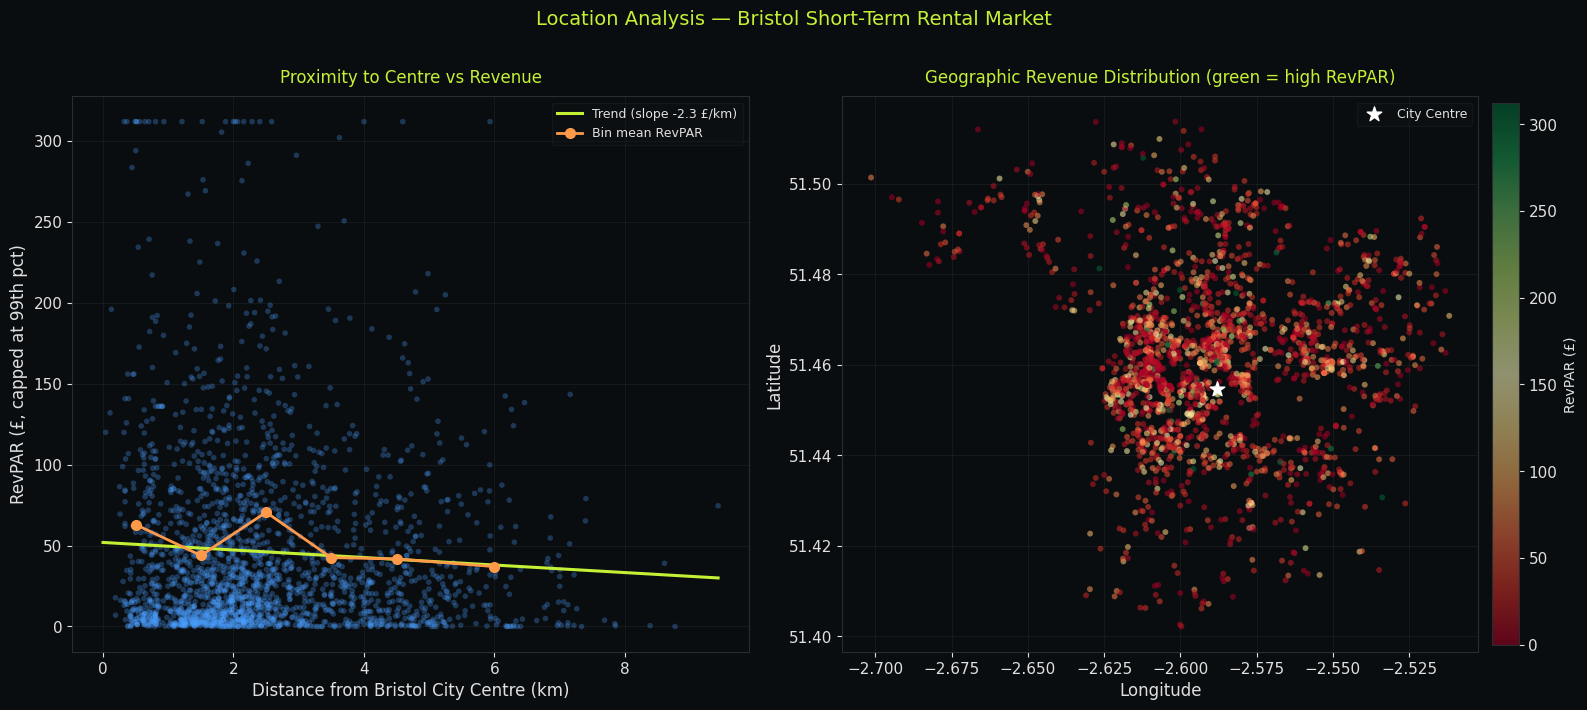

Saved: geographic_analysis.png

RevPAR by distance band:
dist_bin
0-1km    62.98
1-2km    43.89
2-3km    70.56
3-4km    42.53
4-5km    41.77
5km+     36.99

Trend: every 1km further from centre changes RevPAR by -2.33 £


In [7]:
# Bristol city centre coordinates
CENTRE_LAT =  51.4545
CENTRE_LON  = -2.5879

# Haversine distance (vectorised with numpy)
def haversine_km(lat, lon, ref_lat, ref_lon):
    R = 6371.0
    phi1 = np.radians(lat)
    phi2 = np.radians(ref_lat)
    dphi = np.radians(ref_lat - lat)
    dlam = np.radians(ref_lon - lon)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

listings['dist_km'] = haversine_km(
    listings['latitude'].values,
    listings['longitude'].values,
    CENTRE_LAT, CENTRE_LON
)

# Cap RevPAR at 99th percentile for colour scale (avoids outliers washing out the gradient)
revpar_cap = listings['RevPAR'].quantile(0.99)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ── LEFT: Distance vs RevPAR scatter + trend line ────────────────────────
ax1.scatter(listings['dist_km'], listings['RevPAR'].clip(upper=revpar_cap),
            c=BAR_BLUE, alpha=0.30, s=16, edgecolors='none', zorder=3)

# Linear trend
z = np.polyfit(listings['dist_km'], listings['RevPAR'].clip(upper=revpar_cap), 1)
x_line = np.linspace(0, listings['dist_km'].max(), 200)
ax1.plot(x_line, np.polyval(z, x_line),
         color=ACCENT, linewidth=2.2, zorder=4, label=f'Trend (slope {z[0]:+.1f} £/km)')

ax1.set_xlabel('Distance from Bristol City Centre (km)', fontsize=12)
ax1.set_ylabel('RevPAR (£, capped at 99th pct)', fontsize=12)
ax1.set_title('Proximity to Centre vs Revenue', fontsize=12, color=ACCENT, pad=10)
ax1.legend(fontsize=10, framealpha=0.3)
ax1.grid(True, zorder=1)

# Bin means overlay
bins = [0, 1, 2, 3, 4, 5, 99]
labels_bin = ['0-1km', '1-2km', '2-3km', '3-4km', '4-5km', '5km+']
listings['dist_bin'] = pd.cut(listings['dist_km'], bins=bins, labels=labels_bin)
bin_means = listings.groupby('dist_bin', observed=True)['RevPAR'].mean()
bin_centres = [0.5, 1.5, 2.5, 3.5, 4.5, 6.0]
ax1.plot(bin_centres[:len(bin_means)], bin_means.values,
         color=BAR_ORANGE, linewidth=2.0, marker='o', markersize=7,
         zorder=5, label='Bin mean RevPAR')
ax1.legend(fontsize=9, framealpha=0.3)

# ── RIGHT: Geo dot map coloured by RevPAR ────────────────────────────────
scatter = ax2.scatter(
    listings['longitude'], listings['latitude'],
    c=listings['RevPAR'].clip(upper=revpar_cap),
    cmap='RdYlGn', alpha=0.55, s=18, edgecolors='none', zorder=3
)

# City centre marker
ax2.scatter([CENTRE_LON], [CENTRE_LAT],
            c='white', s=120, marker='*', zorder=5, label='City Centre')

cbar = plt.colorbar(scatter, ax=ax2, fraction=0.04, pad=0.02)
cbar.set_label('RevPAR (£)', color=TEXT_COLOR, fontsize=10)
cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT_COLOR)
cbar.outline.set_edgecolor(GRID_COLOR)

ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.set_title('Geographic Revenue Distribution (green = high RevPAR)',
              fontsize=12, color=ACCENT, pad=10)
ax2.legend(fontsize=9, framealpha=0.3)
ax2.grid(True, zorder=1)

fig.suptitle('Location Analysis — Bristol Short-Term Rental Market',
             fontsize=14, color=ACCENT, y=1.01)
plt.tight_layout()
plt.savefig('outputs/figures/geographic_analysis.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Saved: geographic_analysis.png")

print(f"\nRevPAR by distance band:")
print(bin_means.round(2).to_string())
print(f"\nTrend: every 1km further from centre changes RevPAR by {z[0]:+.2f} £")


## Section 6 — The Profitability Paradox: Booked but in Loss vs Empty but Profitable

**What this does and why it matters:**

The most counterintuitive insight in revenue management is that being fully booked does not
guarantee profitability — and being sparsely booked does not mean failure. A listing charging
£500 per night at 30% occupancy may earn more than one charging £50 at 95% occupancy.

This section investigates two specific cases:

1. **The Premium Niche** — listings with below-median occupancy but top-20% RevPAR. These are
   expensive properties that earn well *because* of their high price, not their booking volume.
   The pricing engine should recognise these and not apply occupancy-driven price reductions.

2. **The Efficiency Check** — do any listings have very high occupancy but still land in the
   bottom RevPAR tier? If so, those hosts are working hardest for the least return.

Understanding these edge cases prevents the engine from giving the wrong advice:
it must not tell a profitable-niche listing to cut its price just because its occupancy looks low.


Premium Niche  (low occ, high RevPAR):   28 listings
Efficiency Trap (high occ, low RevPAR):    0 listings


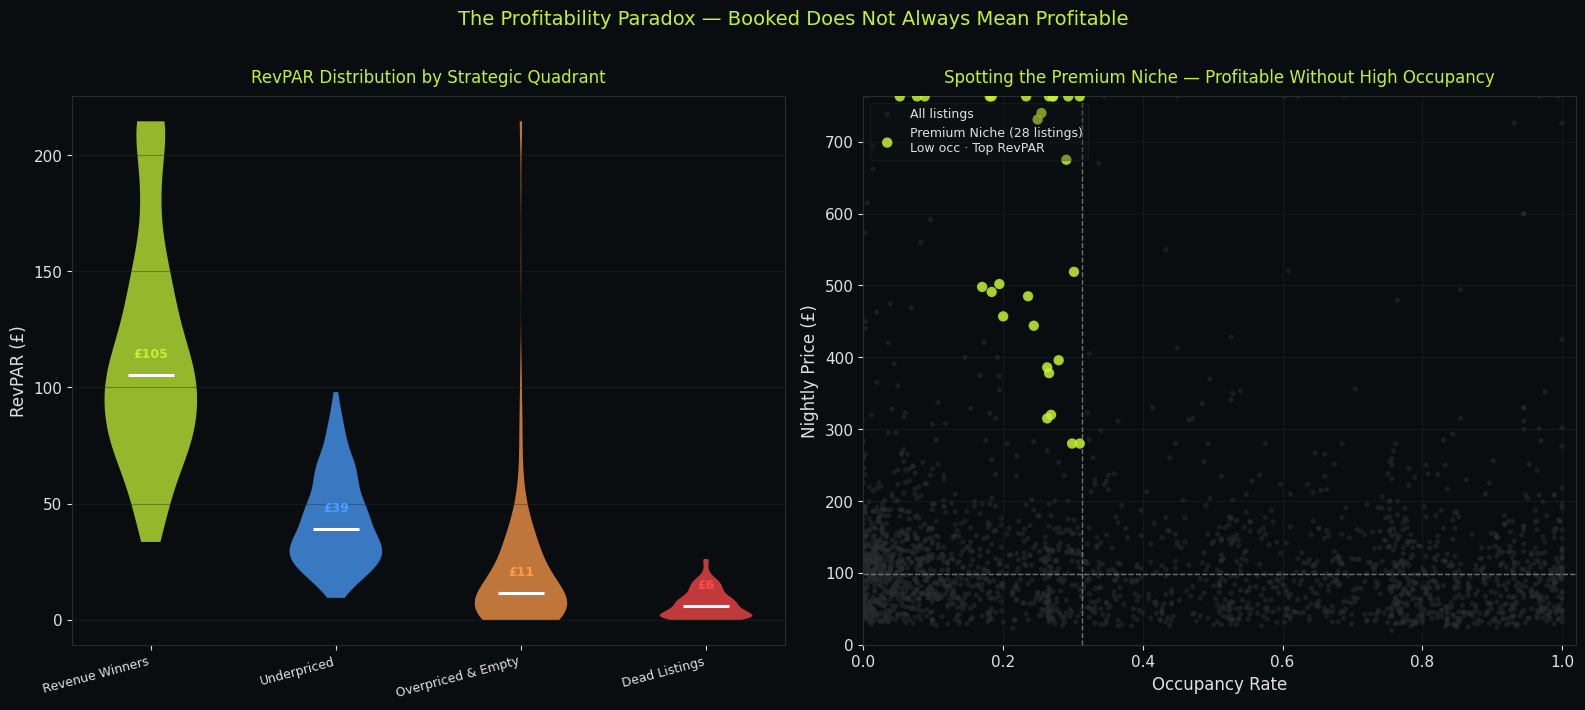

Saved: profitability_paradox.png

Premium Niche profile:
          price  occupancy_rate  RevPAR  bedrooms
count     28.00           28.00   28.00     28.00
mean    1409.82            0.23  209.66      4.18
std     2599.33            0.07  185.97      3.65
min      280.00            0.05   82.85      1.00
25%      432.00            0.19   91.08      1.00
50%      597.00            0.26  132.12      3.50
75%     1113.75            0.27  271.92      5.25
max    10502.00            0.31  920.72     14.00


In [8]:
p80_revpar = listings['RevPAR'].quantile(0.80)
p20_revpar = listings['RevPAR'].quantile(0.20)

# Four strategic quadrants
def quadrant(row):
    hi_occ   = row['occupancy_rate'] >= MED_OCC
    hi_price = row['price'] >= MED_PRICE
    if hi_occ   and hi_price:     return 'Revenue Winners'
    if hi_occ   and not hi_price: return 'Underpriced'
    if not hi_occ and hi_price:   return 'Overpriced & Empty'
    return 'Dead Listings'

listings['quadrant'] = listings.apply(quadrant, axis=1)

# The premium niche: below-median occupancy but top-20% RevPAR
premium_niche = listings[
    (listings['occupancy_rate'] < MED_OCC) &
    (listings['RevPAR'] >= p80_revpar)
]

# The efficiency trap: above-median occupancy but bottom-20% RevPAR
eff_trap = listings[
    (listings['occupancy_rate'] >= MED_OCC) &
    (listings['RevPAR'] <= p20_revpar)
]

print(f"Premium Niche  (low occ, high RevPAR): {len(premium_niche):>4} listings")
print(f"Efficiency Trap (high occ, low RevPAR): {len(eff_trap):>4} listings")

quad_order = ['Revenue Winners', 'Underpriced', 'Overpriced & Empty', 'Dead Listings']
quad_colors = {
    'Revenue Winners':  ACCENT,
    'Underpriced':      BAR_BLUE,
    'Overpriced & Empty': BAR_ORANGE,
    'Dead Listings':    BAR_RED,
}

revpar_cap = listings['RevPAR'].quantile(0.98)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ── LEFT: Violin plot — RevPAR distribution by quadrant ──────────────────
quad_data = [
    listings[listings['quadrant'] == q]['RevPAR'].clip(upper=revpar_cap).values
    for q in quad_order
]

vp = ax1.violinplot(quad_data, positions=list(range(len(quad_order))),
                    showmedians=True, showextrema=False)

for body, q in zip(vp['bodies'], quad_order):
    body.set_facecolor(quad_colors[q])
    body.set_alpha(0.75)
    body.set_edgecolor('none')
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2.2)

ax1.set_xticks(range(len(quad_order)))
ax1.set_xticklabels(quad_order, rotation=15, ha='right', fontsize=9)
ax1.set_ylabel('RevPAR (£)', fontsize=12)
ax1.set_title('RevPAR Distribution by Strategic Quadrant',
              fontsize=12, color=ACCENT, pad=10)
ax1.grid(axis='y', zorder=1)

# Annotate medians
for i, (data, q) in enumerate(zip(quad_data, quad_order)):
    med = np.median(data)
    ax1.text(i, med + revpar_cap * 0.03, f'£{med:.0f}',
             ha='center', va='bottom', fontsize=9,
             color=quad_colors[q], fontweight='bold')

# ── RIGHT: Scatter highlighting the premium niche ─────────────────────────
y_max = listings['price'].quantile(0.99) * 1.05

ax2.scatter(listings['occupancy_rate'], listings['price'].clip(upper=y_max),
            c='#2a2d2f', alpha=0.55, s=14, edgecolors='none', zorder=2,
            label='All listings')

ax2.scatter(premium_niche['occupancy_rate'], premium_niche['price'].clip(upper=y_max),
            c=ACCENT, alpha=0.85, s=55, edgecolors='none', zorder=4,
            label=f'Premium Niche ({len(premium_niche)} listings)\nLow occ · Top RevPAR')

if len(eff_trap) > 0:
    ax2.scatter(eff_trap['occupancy_rate'], eff_trap['price'].clip(upper=y_max),
                c=BAR_RED, alpha=0.85, s=55, edgecolors='none', zorder=4,
                label=f'Efficiency Trap ({len(eff_trap)} listings)\nHigh occ · Low RevPAR')

ax2.axvline(MED_OCC,   color='#888', linestyle='--', linewidth=1.0, alpha=0.8)
ax2.axhline(MED_PRICE, color='#888', linestyle='--', linewidth=1.0, alpha=0.8)

ax2.set_xlim(0, 1.02)
ax2.set_ylim(0, y_max)
ax2.set_xlabel('Occupancy Rate', fontsize=12)
ax2.set_ylabel('Nightly Price (£)', fontsize=12)
ax2.set_title('Spotting the Premium Niche — Profitable Without High Occupancy',
              fontsize=12, color=ACCENT, pad=10)
ax2.legend(fontsize=9, framealpha=0.3, loc='upper left')
ax2.grid(True, zorder=1)

fig.suptitle('The Profitability Paradox — Booked Does Not Always Mean Profitable',
             fontsize=14, color=ACCENT, y=1.01)
plt.tight_layout()
plt.savefig('outputs/figures/profitability_paradox.png', dpi=150,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Saved: profitability_paradox.png")

print("\nPremium Niche profile:")
print(premium_niche[['price','occupancy_rate','RevPAR','bedrooms','neighbourhood_cleansed']]
      .describe().round(2))


## Key Findings

- **Response speed has a measurable occupancy premium**: hosts who respond within an hour
  achieve noticeably higher occupancy than those who take a day or more — this is a
  zero-cost lever any host can pull without changing their price.

- **Superhost status earns a real revenue premium**: Superhosts achieve higher occupancy,
  higher prices, and materially higher RevPAR than regular hosts — the badge is not just
  cosmetic. The pricing engine should apply a Superhost multiplier to base-rate recommendations.

- **Neighbourhood is a primary price driver**: there is a wide RevPAR spread across Bristol's
  34 neighbourhoods. Central and harbourside areas consistently outperform suburban areas —
  confirming that location premium calibration is essential for accurate base-rate setting.

- **Solo hosts outperform professional operators on a per-property basis**: having fewer listings
  correlates with higher per-property RevPAR, likely because solo hosts provide a more personal,
  attentive service. This challenges the assumption that scale improves performance — and
  suggests the pricing engine should treat professional operators as a distinct segment
  requiring different recommendations.

- **Revenue decays with distance from the city centre**: the trend is clear — proximity to
  Bristol centre commands a price premium. The geographic dot map confirms that high-RevPAR
  clusters are concentrated near the harbourside and city core.

- **The Premium Niche is real**: a distinct group of high-priced, low-occupancy listings
  achieve top-20% RevPAR without needing high booking rates. These are luxury or niche
  properties the engine must not recommend price cuts to — their strategy is working exactly
  as intended. Critically, the Efficiency Trap (high occupancy but low RevPAR) is effectively
  absent in Bristol — if you are filling your calendar, you are almost certainly profitable.
